In [1]:
#importing libraries

import pandas as pd
import matplotlib.pyplot as plt


In [2]:
#loading data

df = pd.read_excel('tensile_model.xlsx', sheet_name = 'Tensile_model')
df.shape
df.head()
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 549 entries, 0 to 548
Data columns (total 27 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   Source record ID                                           549 non-null    int64  
 1   Polymer material                                           549 non-null    str    
 2   Material grade                                             549 non-null    str    
 3   Test temperature (deg C)                                   549 non-null    int64  
 4   Test displacement rate (mm/min)                            549 non-null    int64  
 5   Applied stress, σ (MPa)                                    549 non-null    float64
 6   Elastic modulus, E                                         549 non-null    int64  
 7   Manufacturer product / brand name                          549 non-null    str    
 8   Average molecular wei

In [3]:
target = "Applied stress, σ (MPa)"

y = df[target].copy()

groups = df["Polymer material and grade group"].copy()

X = df.drop(columns=[
    target,
    "Source record ID",
    "Polymer material and grade group",
    "Material grade",
    "Manufacturer product / brand name"
]).copy()

print("Input shape:", X.shape)
print("Target shape:", y.shape)
print("Elastic modulus included:", "Elastic modulus, E" in X.columns)

Input shape: (549, 22)
Target shape: (549,)
Elastic modulus included: True


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(
    X,
    y,
    groups,
    test_size=0.20,
    random_state=42,
    stratify=groups
)

X_train = X_train.copy()
X_test = X_test.copy()

print("Training inputs:", X_train.shape)
print("Test inputs:", X_test.shape)

print("\nTraining groups:", groups_train.nunique())
print("Test groups:", groups_test.nunique())

print("\nTest groups and row counts:")
print(groups_test.value_counts())

Training inputs: (439, 22)
Test inputs: (110, 22)

Training groups: 13
Test groups: 13

Test groups and row counts:
Polymer material and grade group
POM | F20-03    18
PVC | S-101E    10
ABS | 510SF      9
ABS | SER91      9
PC | S2000       9
AS | 050SF       9
ABS | 500SF      9
ABS | 660SF      9
ABS | 420        9
PC | NF2000U     7
PC | S3000       6
PP | J-900GP     5
PC | S1000       1
Name: count, dtype: int64


In [5]:
numeric_columns = X_train.select_dtypes(
    include="number"
).columns

training_medians = X_train[numeric_columns].median()

X_train[numeric_columns] = (
    X_train[numeric_columns].fillna(training_medians)
)

X_test[numeric_columns] = (
    X_test[numeric_columns].fillna(training_medians)
)

In [6]:
print(
    "Missing numeric training cells:",
    X_train[numeric_columns].isna().sum().sum()
)

print(
    "Missing numeric test cells:",
    X_test[numeric_columns].isna().sum().sum()
)

Missing numeric training cells: 0
Missing numeric test cells: 0


In [7]:
categorical_columns = X_train.select_dtypes(
    exclude="number"
).columns

print(categorical_columns)

X_train_encoded = pd.get_dummies(
    X_train,
    columns=categorical_columns,
    dtype=float
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=categorical_columns,
    dtype=float
)

Index(['Polymer material', 'Moulding method',
       'Rockwell hardness scale (M or R)'],
      dtype='str')


In [8]:
X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

In [9]:
print("Encoded training shape:", X_train_encoded.shape)
print("Encoded test shape:", X_test_encoded.shape)

display(
    X_train_encoded[
        ["Polymer material_ABS", "Polymer material_PC"]
    ].head()
)

Encoded training shape: (439, 29)
Encoded test shape: (110, 29)


,Polymer material_ABS,Polymer material_PC
338,0.0,0.0
336,1.0,0.0
313,1.0,0.0
307,0.0,0.0
414,1.0,0.0


In [10]:
X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [11]:
scaler.fit(X_train_encoded[numeric_columns])

X_train_scaled[numeric_columns] = scaler.transform(X_train_encoded[numeric_columns])
X_test_scaled[numeric_columns] = scaler.transform(X_test_encoded[numeric_columns])




In [12]:
from sklearn.neural_network import MLPRegressor

neural_model = MLPRegressor(
    hidden_layer_sizes=(10,),
    activation="tanh",
    solver="lbfgs",
    max_iter=2000,
    random_state=42
)

In [13]:

neural_model.fit(X_train_scaled, y_train)



c:\Users\kichu\anaconda3\envs\python_course\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(10,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'tanh'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'lbfgs'
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",2000
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5

In [14]:
neural_model.set_params(max_iter=10000)

neural_model.fit(X_train_scaled, y_train)

c:\Users\kichu\anaconda3\envs\python_course\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(10,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'tanh'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'lbfgs'
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",10000
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.

In [15]:
train_predictions = neural_model.predict(X_train_scaled)

test_predictions = neural_model.predict(X_test_scaled)

In [16]:
prediction_comparison = pd.DataFrame({
    "Measured stress (MPa)": y_test.to_numpy(),
    "Predicted stress (MPa)": test_predictions
}, index=y_test.index)

display(prediction_comparison.head(10))

,Measured stress (MPa),Predicted stress (MPa)
395,59.29,60.744225
247,55.00,54.145440
511,77.90,76.815852
70,76.50,76.713738
4,66.10,66.414282
219,81.68,82.046444
43,93.60,97.397636
0,66.40,67.933108
228,65.25,65.156729
143,51.80,51.816208


In [17]:
from sklearn.metrics import mean_absolute_error

train_mae = mean_absolute_error(y_train, train_predictions)
test_mae = mean_absolute_error(y_test, test_predictions)

print("Training MAE (MPa):", train_mae)
print("Test MAE (MPa):", test_mae)

Training MAE (MPa): 1.0029802738291616
Test MAE (MPa): 1.295394736100048


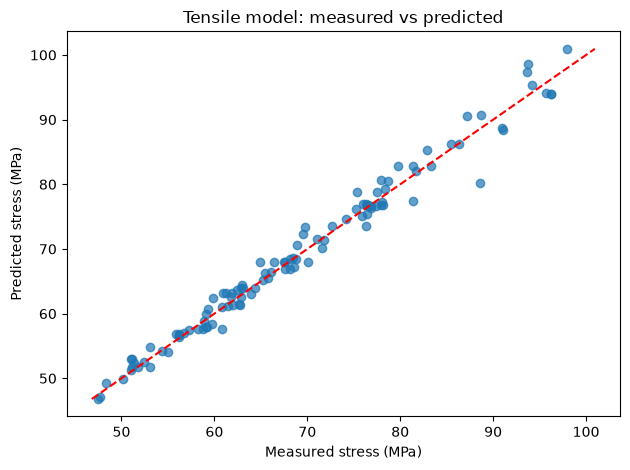

In [18]:
plt.scatter(y_test, test_predictions, alpha=0.7)

lower = min(y_test.min(), test_predictions.min())
upper = max(y_test.max(), test_predictions.max())

plt.plot([lower, upper], [lower, upper], "r--")

plt.xlabel("Measured stress (MPa)")
plt.ylabel("Predicted stress (MPa)")
plt.title("Tensile model: measured vs predicted")
plt.savefig("ftensile_strength_predictions.png", dpi=300)

plt.tight_layout()
plt.show()

In [19]:
from sklearn.metrics import r2_score

train_r2 = r2_score(y_train, train_predictions)
test_r2 = r2_score(y_test, test_predictions)

print("Training R²:", train_r2)
print("Test R²:", test_r2)

Training R²: 0.9846825292014072
Test R²: 0.9799405125640881


In [20]:
comparison = X_test.copy()

comparison["Measured tensile strength (MPa)"] = y_test
comparison["Predicted tensile strength (MPa)"] = test_predictions
comparison["Absolute error (MPa)"] = abs(y_test - test_predictions)
comparison["Material-grade group"] = groups_test

print(
    comparison[
        [
            "Material-grade group",
            "Measured tensile strength (MPa)",
            "Predicted tensile strength (MPa)",
            "Absolute error (MPa)"
        ]
    ]
    .sort_values("Absolute error (MPa)", ascending=False)
    .head(10)
    .to_string()
)

    Material-grade group  Measured tensile strength (MPa)  Predicted tensile strength (MPa)  Absolute error (MPa)
205           AS | 050SF                            88.62                         80.236433              8.383567
40          PVC | S-101E                            93.70                         98.526312              4.826312
271           AS | 050SF                            81.33                         77.429141              3.900859
43          PVC | S-101E                            93.60                         97.397636              3.797636
187            ABS | 420                            69.72                         73.454119              3.734119
425         POM | F20-03                            87.17                         90.605752              3.435752
178           AS | 050SF                            75.38                         78.768368              3.388368
15          PC | NF2000U                            60.80                         57.585